<a href="https://colab.research.google.com/github/LayanJunaid/heart-disease-prediction/blob/main/02_EDA_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set_style("whitegrid")

In [52]:
from google.colab import files
uploaded = files.upload()

Saving processed.cleveland.data to processed.cleveland (1).data


In [53]:
column_names = [
    'age','sex','cp','trestbps','chol','fbs',
    'restecg','thalach','exang','oldpeak',
    'slope','ca','thal','condition'
]

df = pd.read_csv(
    "processed.cleveland.data",
    names=column_names
)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [54]:
df['condition'] = df['condition'].apply(lambda x: 0 if x == 0 else 1)

df['condition'].value_counts()

,count
condition,
0,164
1,139


In [55]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    float64
 1   sex        303 non-null    float64
 2   cp         303 non-null    float64
 3   trestbps   303 non-null    float64
 4   chol       303 non-null    float64
 5   fbs        303 non-null    float64
 6   restecg    303 non-null    float64
 7   thalach    303 non-null    float64
 8   exang      303 non-null    float64
 9   oldpeak    303 non-null    float64
 10  slope      303 non-null    float64
 11  ca         303 non-null    object 
 12  thal       303 non-null    object 
 13  condition  303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB

Missing Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope     

In [56]:
numerical = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

categorical = [
    'sex', 'cp', 'fbs', 'restecg',
    'exang', 'slope', 'ca', 'thal'
]

print("Numerical features:", numerical)
print("Categorical features:", categorical)

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


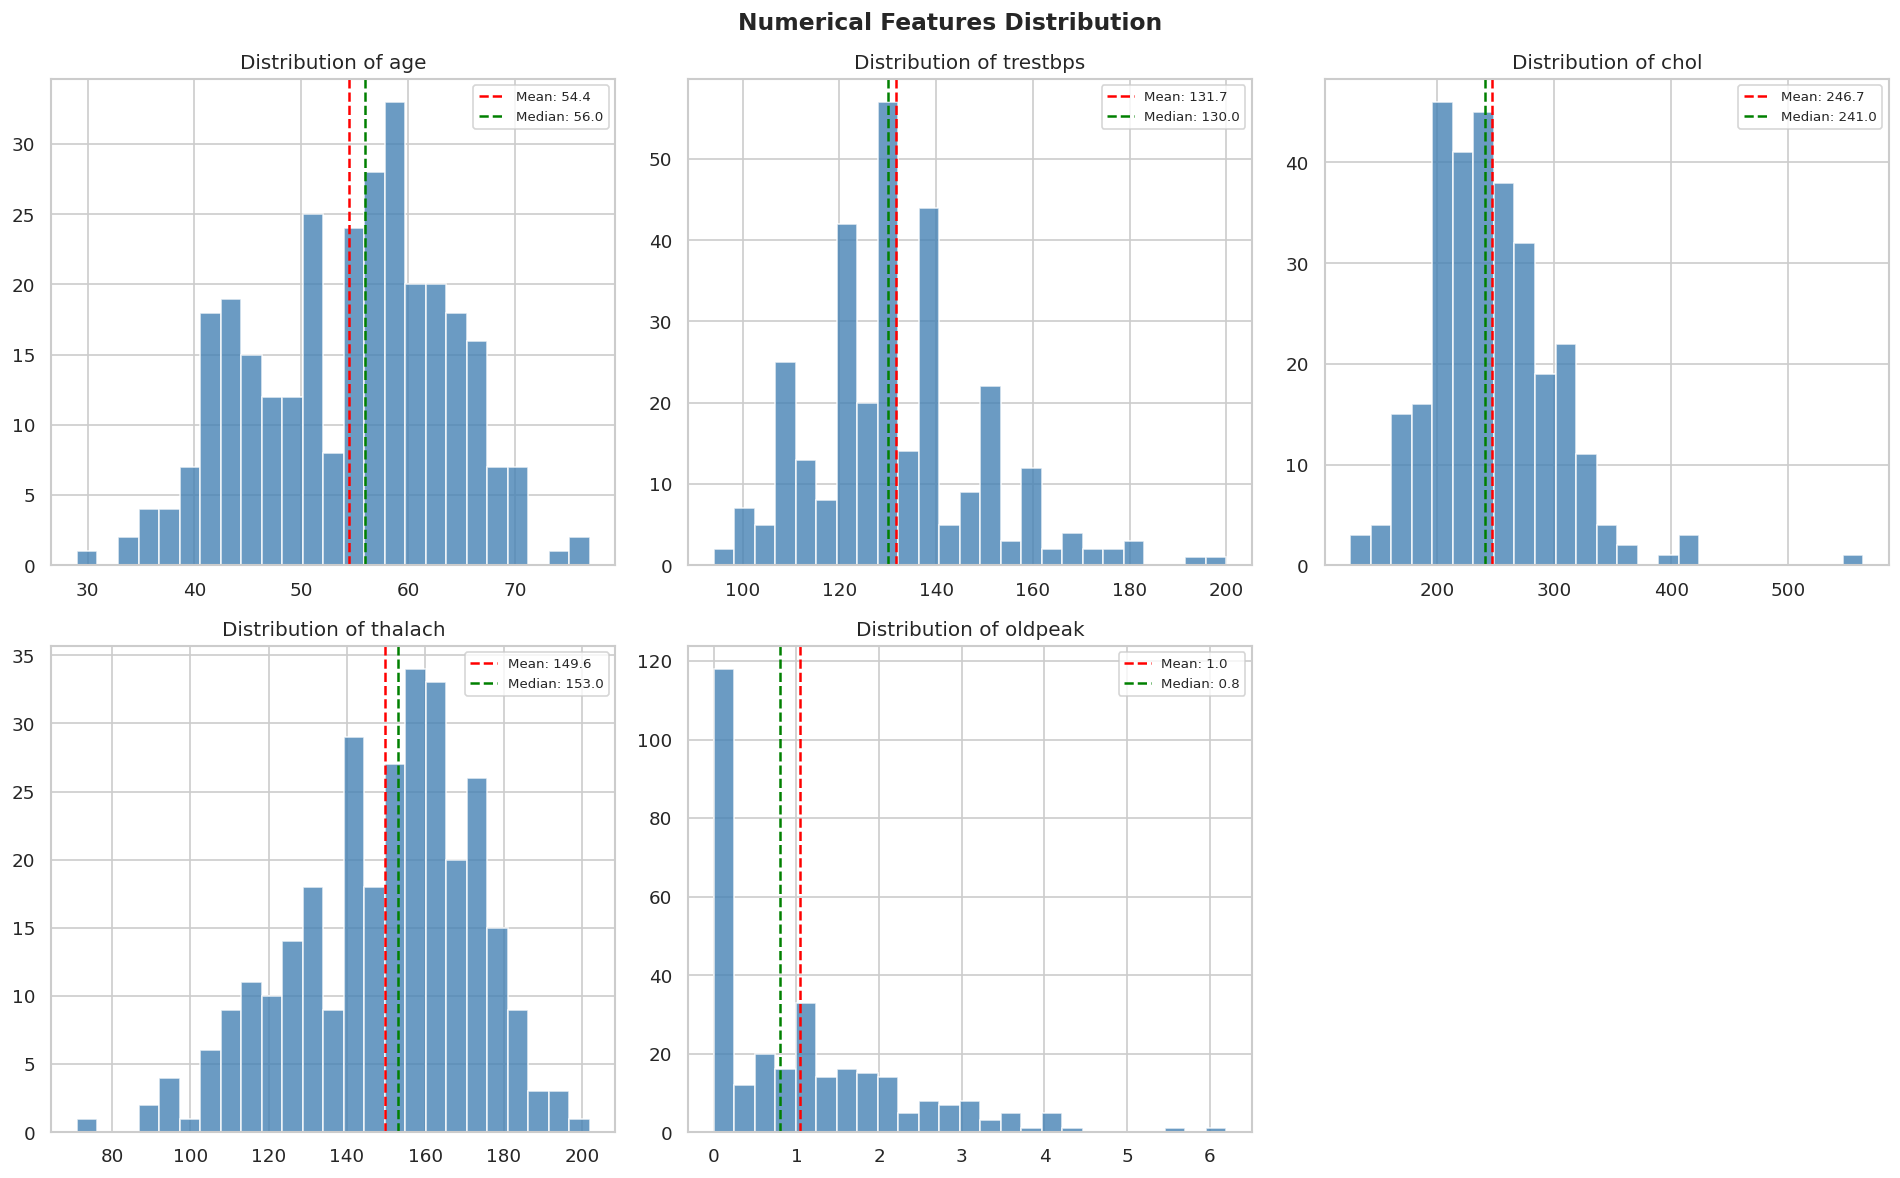

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(numerical):

    axes[i].hist(df[col], bins=25,
                 color='steelblue',
                 edgecolor='white',
                 alpha=0.8)

    axes[i].axvline(df[col].mean(),
                    color='red',
                    linestyle='--',
                    label=f'Mean: {df[col].mean():.1f}')

    axes[i].axvline(df[col].median(),
                    color='green',
                    linestyle='--',
                    label=f'Median: {df[col].median():.1f}')

    axes[i].set_title(f'Distribution of {col}')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)

plt.suptitle('Numerical Features Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

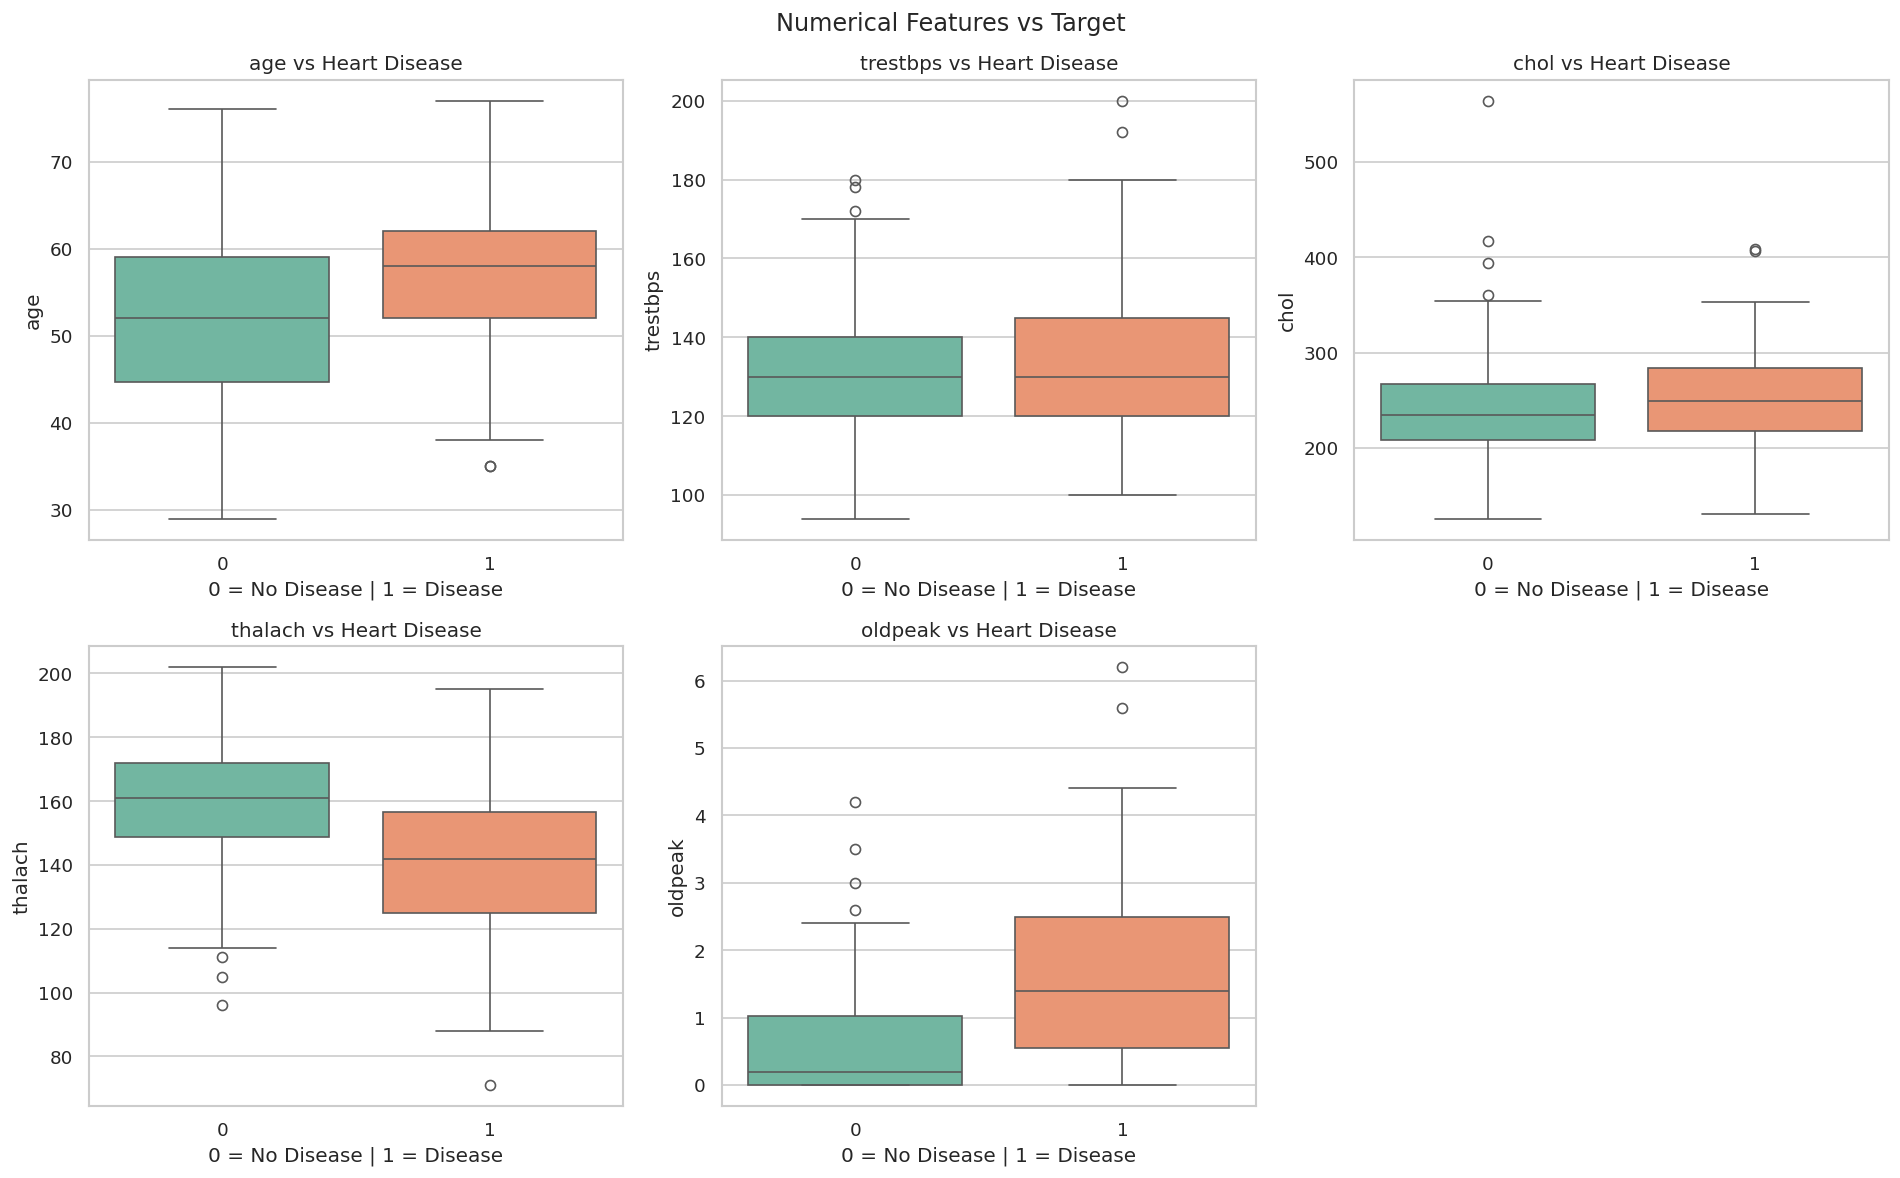

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(numerical):

    sns.boxplot(x='condition',
                y=col,
                data=df,
                palette='Set2',
                ax=axes[i])

    axes[i].set_title(f'{col} vs Heart Disease')
    axes[i].set_xlabel('0 = No Disease | 1 = Disease')

axes[-1].set_visible(False)

plt.suptitle('Numerical Features vs Target')

plt.tight_layout()
plt.show()

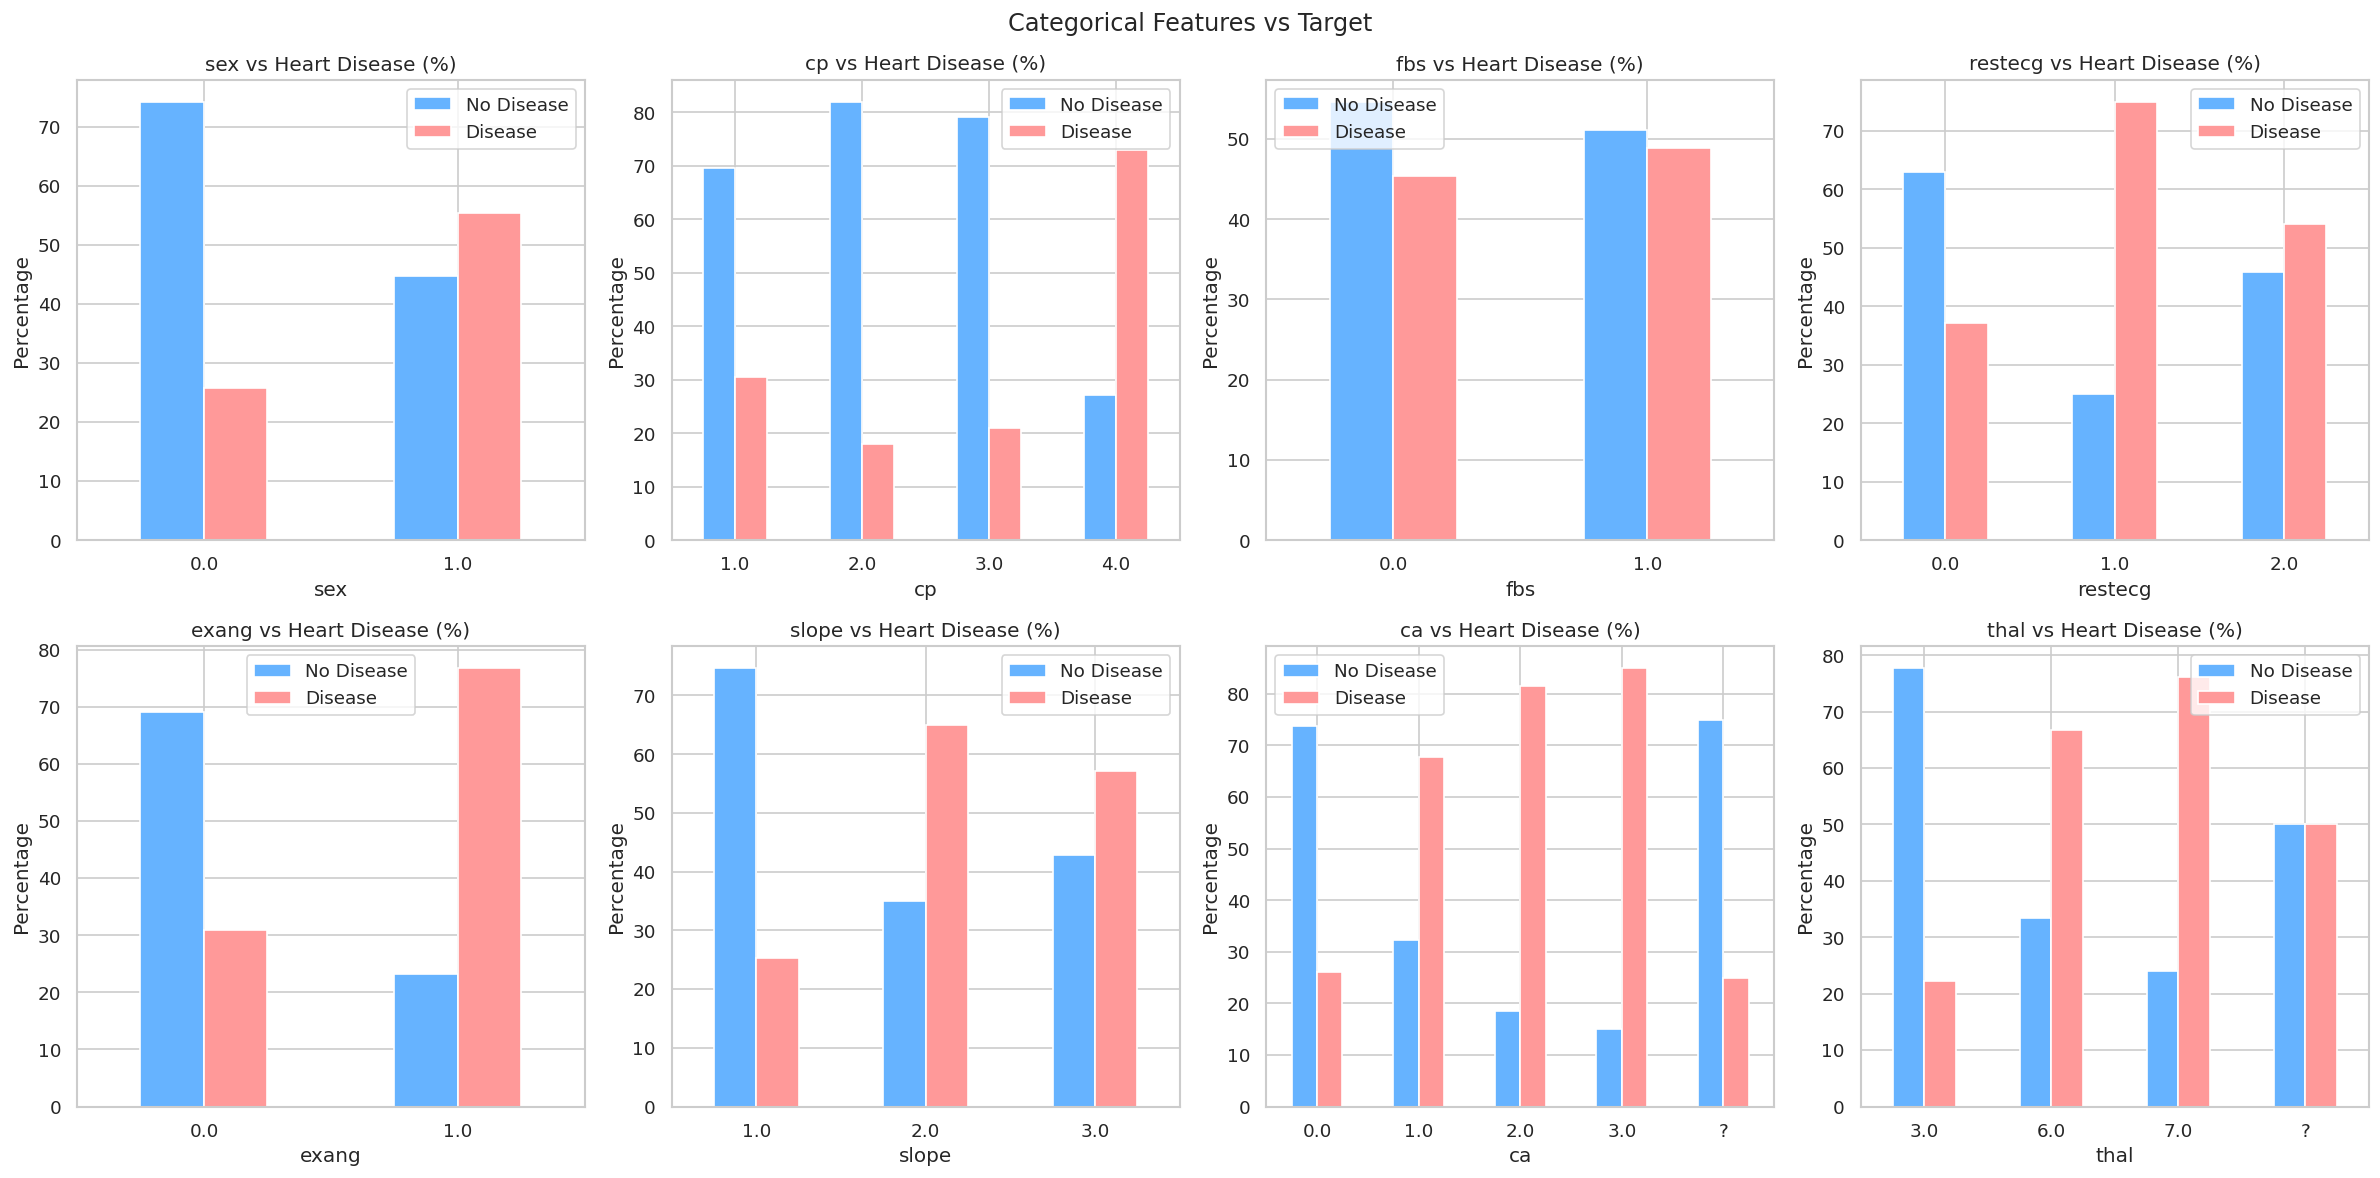

In [59]:
fig, axes = plt.subplots(2,4, figsize=(20,10))
axes = axes.flatten()

for i, col in enumerate(categorical):

    ct = pd.crosstab(df[col], df['condition'],
                     normalize='index') * 100

    ct.plot(kind='bar',
            ax=axes[i],
            color=['#66b3ff','#ff9999'],
            edgecolor='white',
            rot=0)

    axes[i].set_title(f'{col} vs Heart Disease (%)')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(['No Disease','Disease'])

plt.suptitle('Categorical Features vs Target')

plt.tight_layout()
plt.show()

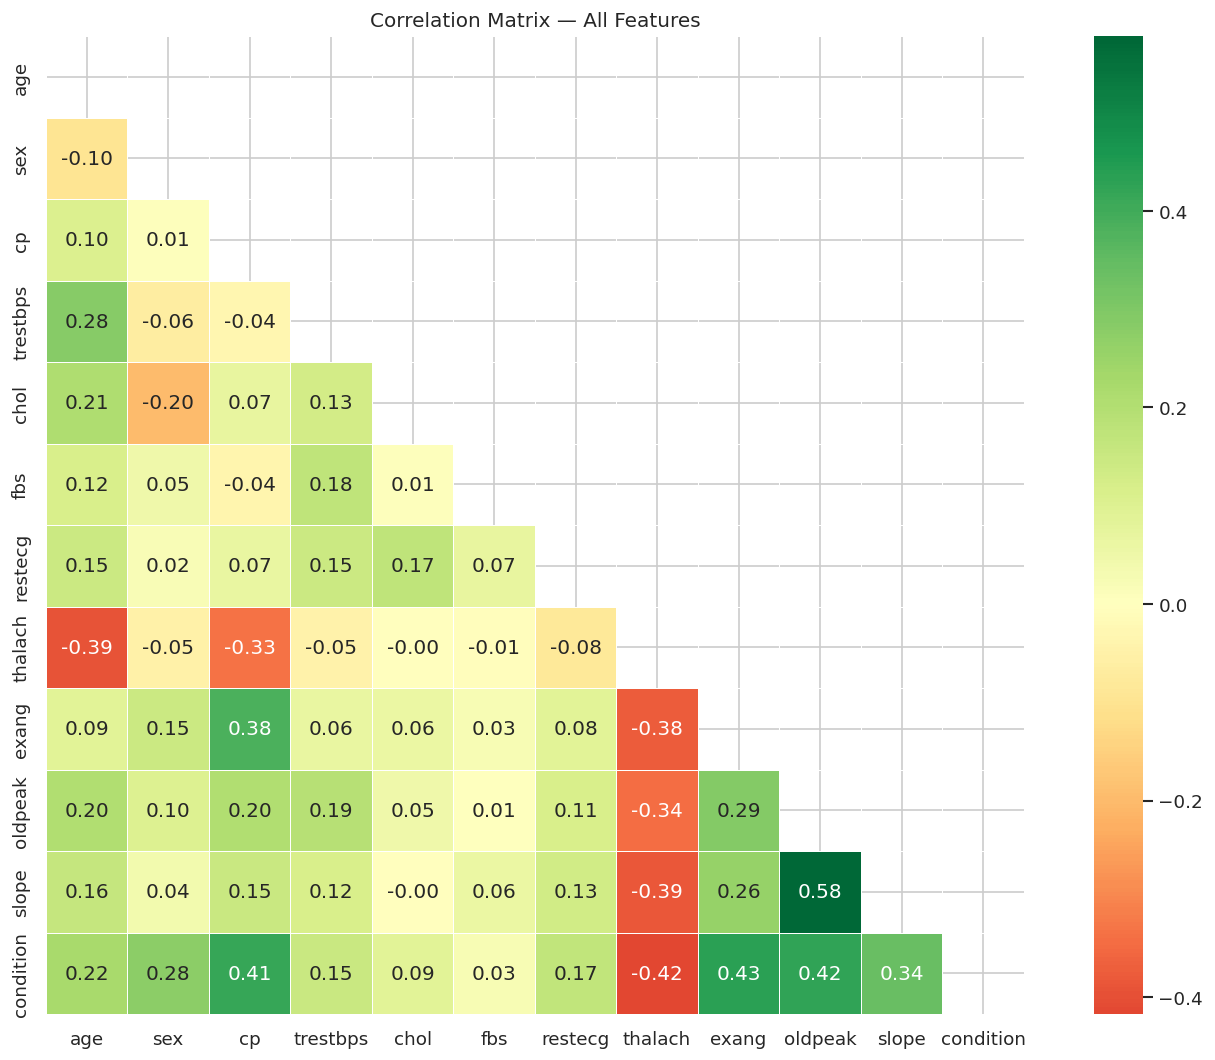

In [60]:
plt.figure(figsize=(12,9))

corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix — All Features')

plt.tight_layout()
plt.show()

In [61]:
target_corr = corr['condition'].drop('condition')\
                               .abs()\
                               .sort_values(ascending=False)

print("Top Correlations with Target:")
display(target_corr)

Top Correlations with Target:


,condition
exang,0.431894
oldpeak,0.424510
thalach,0.417167
cp,0.414446
slope,0.339213
sex,0.276816
age,0.223120
restecg,0.169202
trestbps,0.150825
chol,0.085164


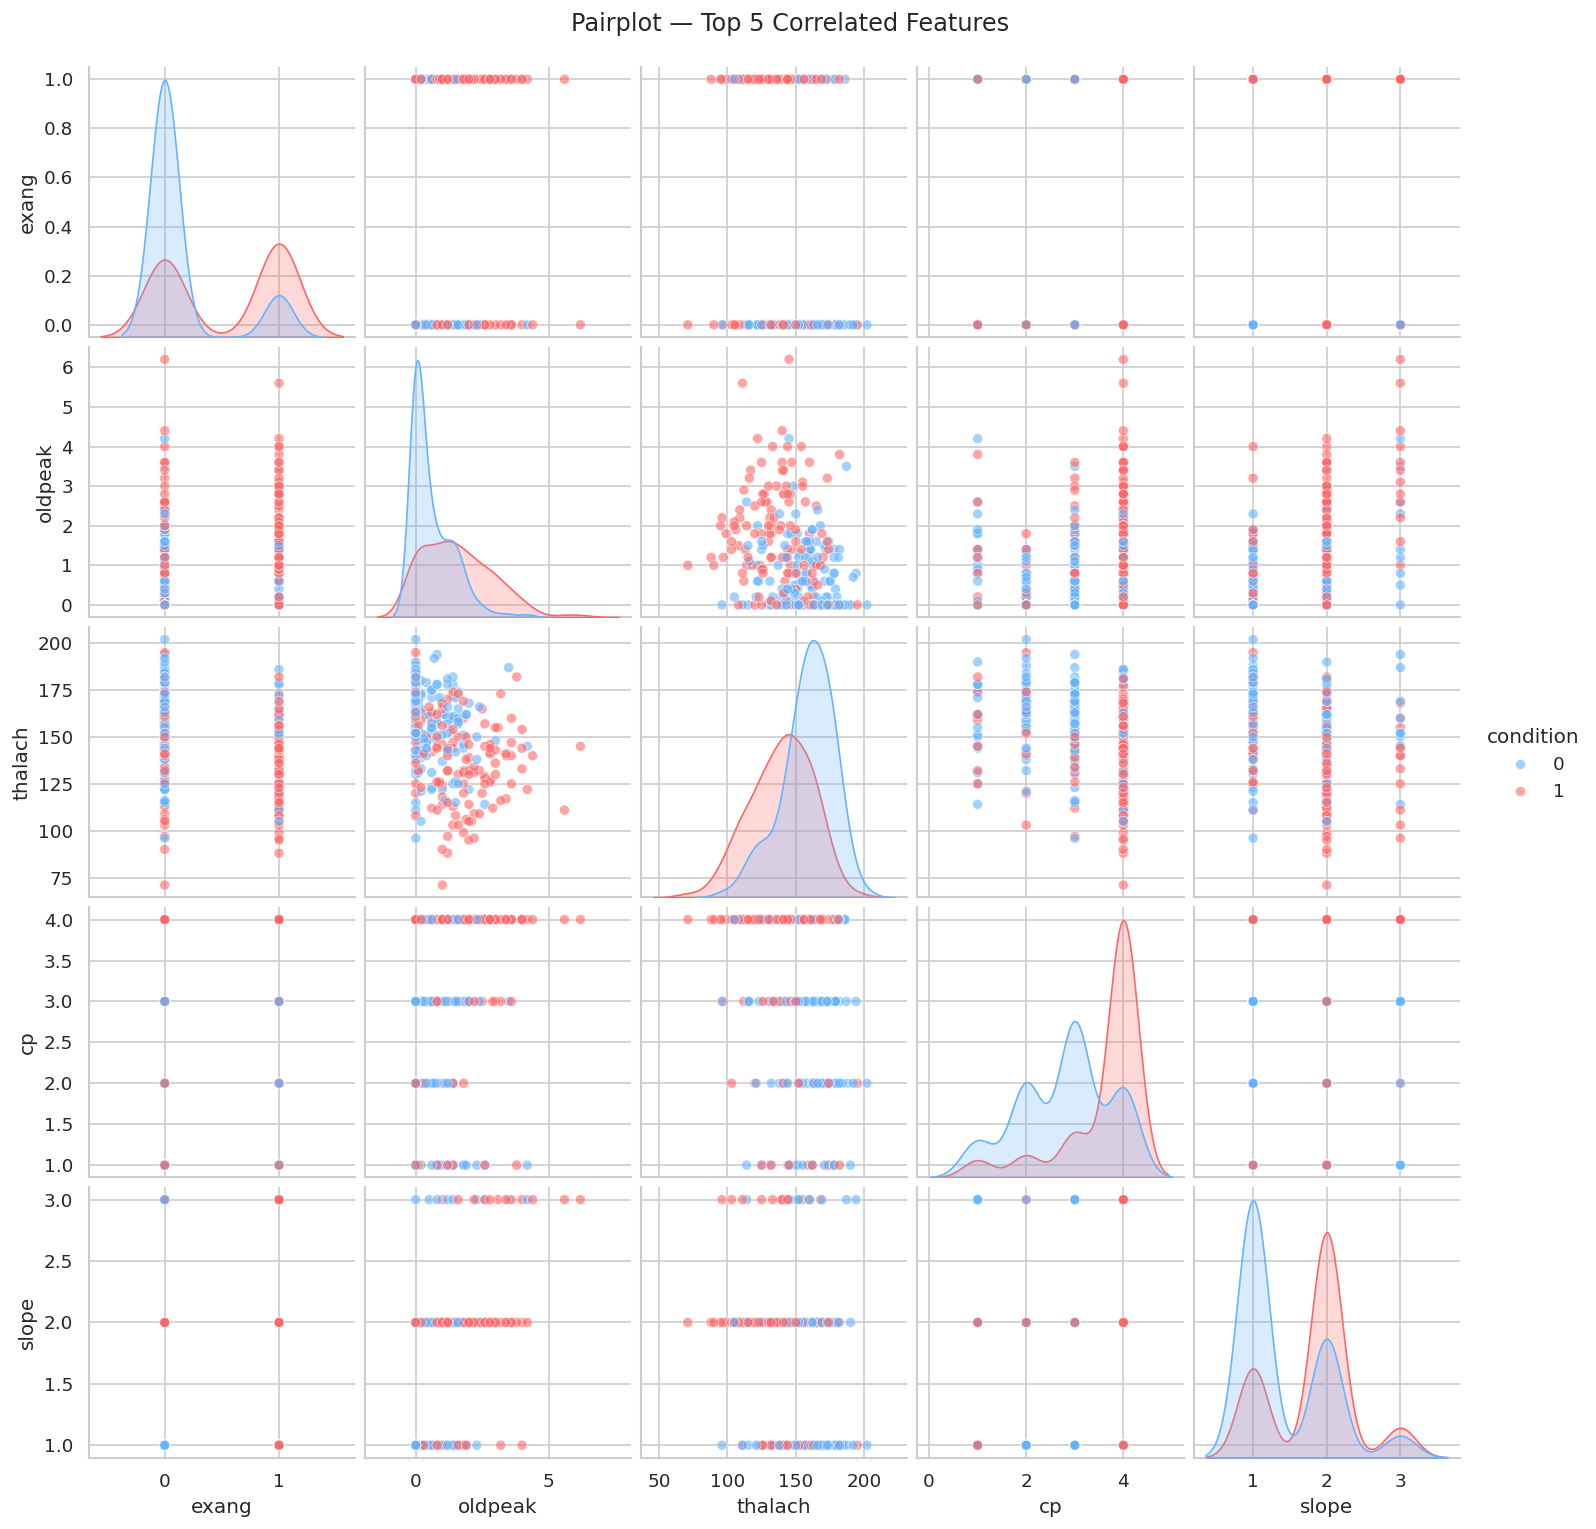

In [62]:
top_features = target_corr.head(5).index.tolist() + ['condition']

sns.pairplot(
    df[top_features],
    hue='condition',
    palette={0:'#66b3ff',1:'#ff6666'},
    plot_kws={'alpha':0.6}
)

plt.suptitle('Pairplot — Top 5 Correlated Features', y=1.02)

plt.show()

In [63]:
outlier_summary = {}

for col in numerical:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) |
                  (df[col] > upper)]

    outlier_summary[col] = {
        'Count': len(outliers),
        'Percentage': f"{len(outliers)/len(df)*100:.1f}%"
    }

pd.DataFrame(outlier_summary).T

,Count,Percentage
age,0,0.0%
trestbps,9,3.0%
chol,5,1.7%
thalach,1,0.3%
oldpeak,5,1.7%
